In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Membaca file CSV ke dalam DataFrame pandas.
df = pd.read_csv('user_data.csv')

df.head()

,user_id,stage,conversion
0,user_0,homepage,True
1,user_1,homepage,True
2,user_2,homepage,True
3,user_3,homepage,True
4,user_4,homepage,True


## Langkah 1: Menghitung Pengguna di Setiap Tahap

In [13]:
# Mendefinisikan urutan yang benar dari tahapan funnel.
stage_order = ['homepage', 'product_page', 'cart', 'checkout', 'purchase']

# Mengelompokkan data berdasarkan 'stage' dan menghitung jumlah pengguna unik di setiap tahap.
funnel_data = df.groupby('stage')['user_id'].nunique().reset_index()
funnel_data.columns = ['stage', 'user_count']

# Mengurutkan data sesuai urutan funnel yang benar
funnel_data['stage'] = pd.Categorical(funnel_data['stage'], categories=stage_order, ordered=True)
funnel_data = funnel_data.sort_values('stage')

funnel_data


,stage,user_count
2,homepage,10000
3,product_page,5000
0,cart,1500
1,checkout,450
4,purchase,225


## Langkah 2: Mengungkap “Tingkat Kebocoran”

In [15]:
# Menghitung konversi dari tahap sebelumnya dan konversi keseluruhan
funnel_data['conversion_rate_from_previous'] = (funnel_data['user_count'] / funnel_data['user_count'].shift(1) * 100).fillna(100)
funnel_data['overall_conversion_rate'] = (funnel_data['user_count'] / funnel_data['user_count'].iloc[0] * 100)


funnel_data

,stage,user_count,conversion_rate_from_previous,overall_conversion_rate
2,homepage,10000,100.0,100.00
3,product_page,5000,50.0,50.00
0,cart,1500,30.0,15.00
1,checkout,450,30.0,4.50
4,purchase,225,50.0,2.25


## Visualisasi adalah Kunci: Membangun Funnel Chart

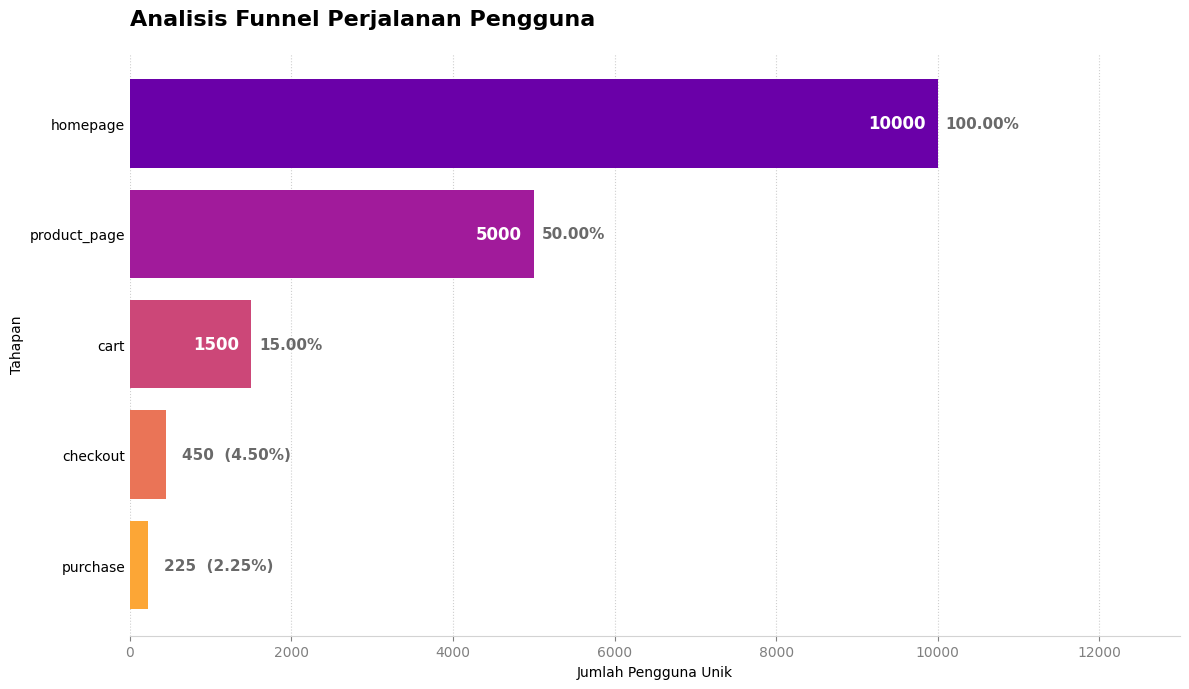

In [30]:
stages = funnel_data['stage']
values = funnel_data['user_count']

# Palet Warna Profesional dan Modern
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(stages)))


# Membuat bar chart horizontal
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(stages, values, color=colors)

ax.invert_yaxis()

# Logika Labeling
max_value = values.max()

for i, bar in enumerate(bars):
    width = bar.get_width()
    overall_conv = funnel_data['overall_conversion_rate'].iloc[i]

    # Cek apakah bar terlalu pendek (kurang dari 15% dari bar terpanjang)
    if width < max_value * 0.15:
        padding = max_value * 0.02
        
        # Jumlah user dan persentase dalam satu label untuk kerapian
        combined_text = f'{int(width)}  ({overall_conv:.2f}%)'
        
        ax.text(width + padding,
                bar.get_y() + bar.get_height() / 2,
                combined_text,
                va='center',
                ha='left',
                fontsize=11,
                color='dimgray',
                weight='semibold')
    else:
        # Label Jumlah Pengguna (di dalam bar)
        ax.text(width - (max_value * 0.015),
                bar.get_y() + bar.get_height() / 2,
                f'{int(width)}',
                va='center',
                ha='right',
                fontsize=12,
                color='white',
                weight='bold')

        # Label Persentase (di luar bar)
        padding = max_value * 0.01
        ax.text(width + padding,
                bar.get_y() + bar.get_height() / 2,
                f'{overall_conv:.2f}%',
                va='center',
                ha='left',
                fontsize=11,
                color='dimgray',
                weight='semibold')


# Styling

ax.set_title(
    'Analisis Funnel Perjalanan Pengguna',
    fontsize=16,
    pad=20,
    weight="bold",
    loc="left"  
)
ax.set_xlabel('Jumlah Pengguna Unik')
ax.set_ylabel('Tahapan')
ax.set_xlim(right=max_value * 1.3) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', colors='gray')
ax.grid(True, axis='x', linestyle=':', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()